In [ ]:
%time
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k, metric, pb, p = 2):
        self.k = k
        self.metric = metric
        self.pb = pb
        self.p = p
    
    def fit(self, x_train, y_train):
        self.x_train = np.array(x_train, dtype=float)
        self.y_train = np.array(y_train)
        if self.metric == "mahalanobis":
            self.cov_matrix = np.cov(self.x_train, rowvar=False)
            # Vérifier si la matrice est “stable”
            eigvals = np.linalg.eigvals(self.cov_matrix)
            if np.min(eigvals) > 1e-10:
                # inverse normal
                self.inv_cov_matrix = np.linalg.inv(self.cov_matrix)
            else:
                # régularisation
                self.inv_cov_matrix = np.linalg.inv(self.cov_matrix + 1e-5 * np.eye(self.cov_matrix.shape[0]))
    
    def distance(self, x1, x2):
        if self.metric == "euclidean":
            return np.linalg.norm(x1 - x2)
        elif self.metric == "cosine":
            denominateur = np.linalg.norm(x1) * np.linalg.norm(x2)
            if denominateur == 0:
                return 0
            return 1 - np.dot(x1, x2) / denominateur
        elif self.metric == "manhattan":
            return np.sum(np.abs(x1 - x2))
        elif self.metric == "minkowski":
            return np.sum(np.abs(x1 - x2) ** self.p) ** (1 / self.p)
        elif self.metric == "hamming":
            return np.sum(x1 != x2) / len(x1)
        elif self.metric == "jaccard":
            intersection = np.sum(np.logical_and(x1, x2))
            union = np.sum(np.logical_or(x1, x2))
            if union == 0:
                return 0
            return 1 - intersection / union
        elif self.metric == "mahalanobis":
            diff = x1 - x2
            return np.sqrt(diff.T @ self.inv_cov_matrix @ diff)
        else:
            raise ValueError(f"Metrique inconnue : {self.metric}.\n Les métriques prises en charge sont : 'euclidean', 'manhattan', 'cosine', 'minkowski', 'hamming', 'jaccard', 'mahalanobis' ")
        
    def predict(self, X_pred):

        X_pred = np.atleast_2d(np.array(X_pred, dtype=float))
        y_pred = []
        
        for x in X_pred: 
            distances = np.array([self.distance(x, x_train) for x_train in self.x_train])
            idx = np.argsort(distances)[:self.k]
            
            if self.pb =='reg':
                y_pred.append(np.mean(self.y_train[idx]))
            elif self.pb == "class":
                y_pred.append(Counter(self.y_train[idx]).most_common(1)[0][0])
            else:
                raise ValueError(f"Type de problème inconnu : {self.pb}.\n Les types de problèmes pris en charge sont : 'reg' pour la régression et 'class' pour la classification.")
        return np.array(y_pred)

CPU times: total: 0 ns
Wall time: 0 ns


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [3]:
df = pd.read_csv("base3.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.duplicated().sum()

0

In [5]:
df.drop("User ID", axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   EstimatedSalary  400 non-null    int64 
 3   Purchased        400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,400.0,37.6550,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,69742.5000,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,0.3575,0.479864,0.0,0.00,0.0,1.0,1.0


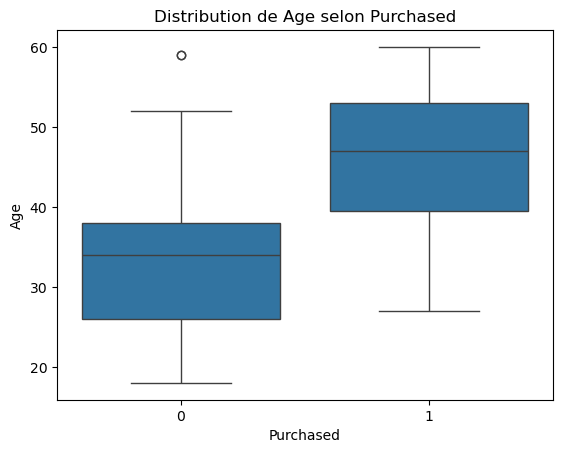

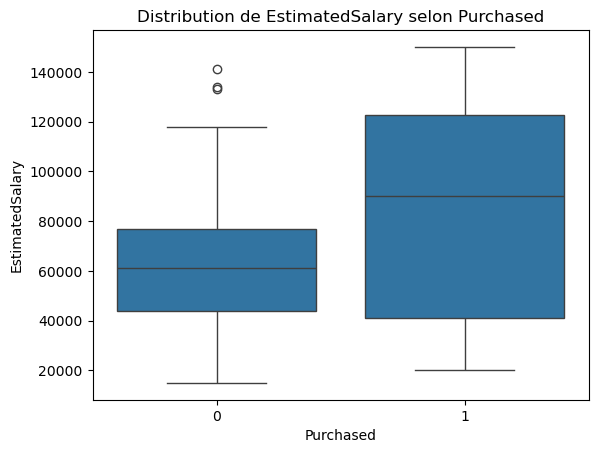

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Purchased", y="Age", data=df)
plt.title("Distribution de Age selon Purchased")
plt.show()

sns.boxplot(x="Purchased", y="EstimatedSalary", data=df)
plt.title("Distribution de EstimatedSalary selon Purchased")
plt.show()

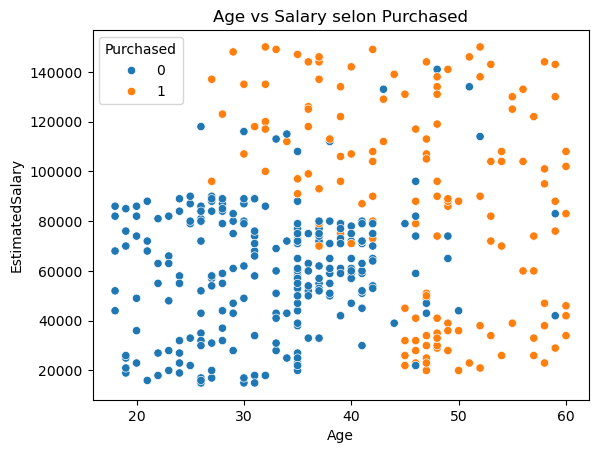

In [8]:
sns.scatterplot(x="Age", y="EstimatedSalary", hue="Purchased", data=df)
plt.title("Age vs Salary selon Purchased")
plt.show()

Text(0.5, 1.0, 'Distribution de la variable cible')

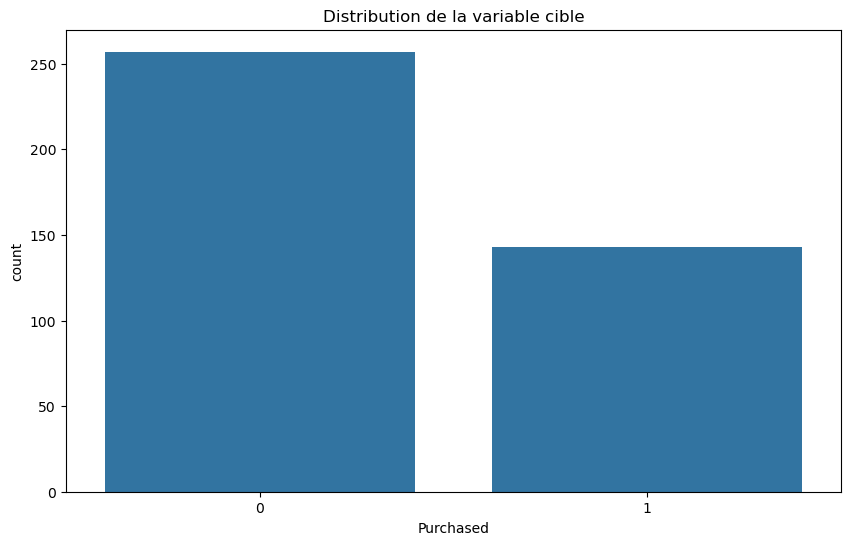

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Purchased', data=df)
plt.title('Distribution de la variable cible')

In [10]:
df.duplicated().sum()

20

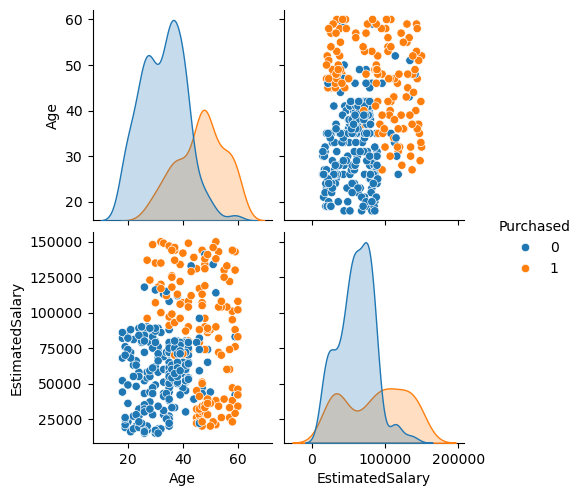

In [11]:
sns.pairplot(df, hue="Purchased")

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_boxplots(d):
    n_cols = len(d.columns)
    n_rows = math.ceil(n_cols / 3)  # 3 plots per row
    
    fig, axs = plt.subplots(n_rows, 3, figsize=(12, 6 * n_rows))
    axs = axs.flatten()
    
    for i, var in enumerate(d.columns):
        if d[var].dtype == 'object' or d[var].dtype.name == 'category':
            # For categorical variables, use countplot
            sns.countplot(x=d[var], ax=axs[i])
        else:
            # For numeric variables, use boxplot
            sns.boxplot(data=d[var], ax=axs[i])
        axs[i].set_title(var)
        
    # Remove empty subplots
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])
    
    plt.tight_layout()
    plt.show()

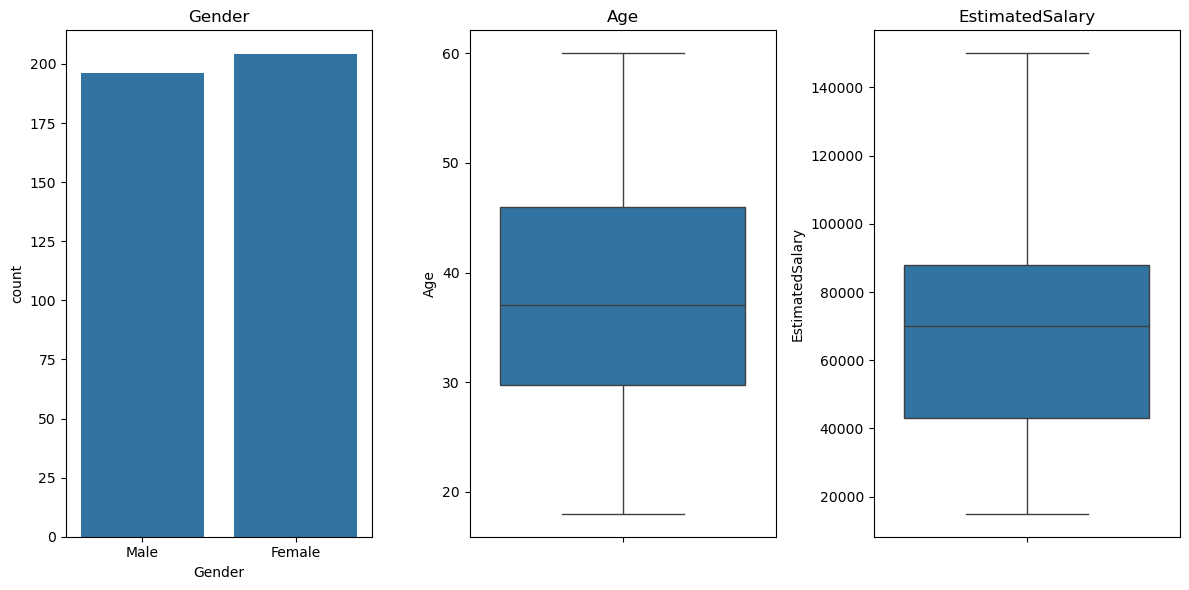

In [13]:
plot_boxplots(df.drop("Purchased", axis=1))

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distributions(df):
    n = len(df.columns)
    n_rows = (n + 2) // 3  # 3 graphiques par ligne
    fig, axs = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axs = axs.flatten()

    for i, col in enumerate(df.columns):
        if df[col].dtype == 'object' or df[col].dtype.name == 'category':
            # Variable catégorielle → countplot
            sns.countplot(x=col, data=df, ax=axs[i])
            axs[i].set_title(f'Distribution de {col} (catég.)')
            axs[i].tick_params(axis='x', rotation=45)
        else:
            # Variable numérique → histogramme + KDE
            sns.histplot(df[col], kde=True, ax=axs[i])
            axs[i].set_title(f'Distribution de {col} (num.)')

    # Supprimer les axes vides
    for j in range(i + 1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()

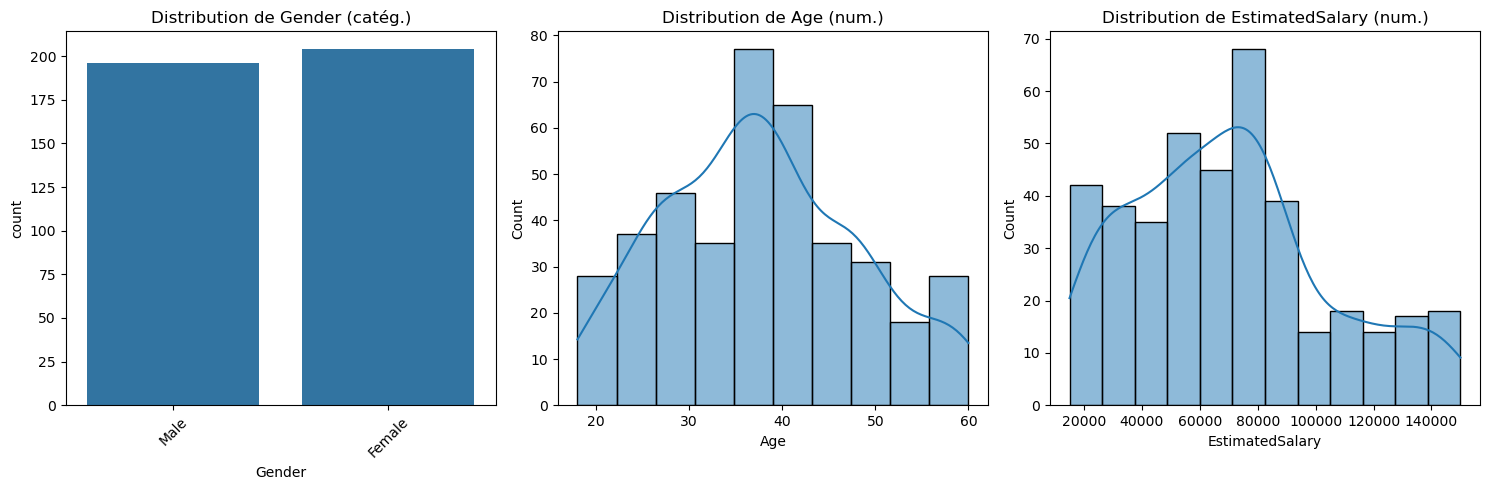

In [15]:
plot_distributions(df.drop("Purchased", axis=1))

In [16]:
y = df["Purchased"]
df.drop("Purchased", axis=1,inplace=True)

In [17]:
# Encodage de la variable catégorielle 
df = pd.get_dummies(df, columns=['Gender']).astype(int)
df.head()

,Age,EstimatedSalary,Gender_Female,Gender_Male
0,19,19000,0,1
1,35,20000,0,1
2,26,43000,1,0
3,27,57000,1,0
4,19,76000,0,1


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int32
 1   EstimatedSalary  400 non-null    int32
 2   Gender_Female    400 non-null    int32
 3   Gender_Male      400 non-null    int32
dtypes: int32(4)
memory usage: 6.4 KB


In [19]:
# Standardisation, encodage et decoupage des données
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train[["Age","EstimatedSalary"]] = scaler.fit_transform(X_train[["Age","EstimatedSalary"]])
X_test[["Age","EstimatedSalary"]] = scaler.transform(X_test[["Age","EstimatedSalary"]])

In [20]:
from sklearn.metrics import classification_report

In [21]:
X_train

,Age,EstimatedSalary,Gender_Female,Gender_Male
3,-1.066752,-0.386344,1,0
18,0.797535,-1.229939,0,1
202,0.110692,1.853544,1,0
250,0.601294,-0.909955,1,0
274,1.876859,-1.288118,1,0
...,...,...,...,...
71,-1.361114,-1.259028,1,0
106,-1.164873,-1.026312,1,0
270,0.503174,1.824455,1,0
348,0.110692,0.195445,0,1


In [ ]:
%time
for k in range(3,15,2) :
    knn = KNN(k=k, metric="euclidean", pb="class")
    knn.fit(X_train,y_train)
    y_pred = knn.predict(X_test)
    print(f"Résultats pour k={k} :")
    print(classification_report(y_test, y_pred))

CPU times: total: 0 ns
Wall time: 0 ns
Résultats pour k=3 :
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        52
           1       0.86      0.86      0.86        28

    accuracy                           0.90        80
   macro avg       0.89      0.89      0.89        80
weighted avg       0.90      0.90      0.90        80

Résultats pour k=5 :
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80

Résultats pour k=7 :
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91   

**Au final k = 9**

### Comparaison avec Sklearn

In [ ]:
%time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

for k in range(3, 15,2):
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train, y_train)           # OK, pas de matrice à inverser
    y_pred = knn.predict(X_test)
    print(f"Résultats pour k={k} :    Sklearn")
    print(classification_report(y_test, y_pred))

CPU times: total: 0 ns
Wall time: 0 ns
Résultats pour k=3 :    Sklearn
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        52
           1       0.89      0.86      0.87        28

    accuracy                           0.91        80
   macro avg       0.91      0.90      0.90        80
weighted avg       0.91      0.91      0.91        80

Résultats pour k=5 :    Sklearn
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80

Résultats pour k=7 :    Sklearn
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93    

In [ ]:
%%time
knn = KNN(k=3, metric="euclidean", pb="reg")

import time
import psutil, os

# Suivi RAM et CPU
process = psutil.Process(os.getpid())
print("RAM avant fit (Mo):", process.memory_info().rss / 1024**2)

# Mesurer le temps de fit
start_time = time.time()
knn.fit(X_train, y_train)
end_time = time.time()
print("Temps pour fit :", end_time - start_time, "secondes")
print("RAM après fit (Mo):", process.memory_info().rss / 1024**2)

# Mesurer le temps pour predict
start_time = time.time()
prediction = knn.predict([5.8, 37])
end_time = time.time()
print("Temps pour predict :", end_time - start_time, "secondes")
print("RAM après predict (Mo):", process.memory_info().rss / 1024**2)

prediction